## N-Gram Language Modeling 

This notebook builds **Unigram,Bigram and Trigram** language models on the Brown + Reuterd corpora.
- add- k smooothing
- linear interpolation
- perplexity
- Generate Text


# What is statistical Language Modeling?
 language model assigns a probability to a sequence of words. Using the
chain rule and the **Markov assumption** (a word depends only on the
previous *n-1* words), an **n-gram** model estimates

$$P(w_i \mid w_1 \dots w_{i-1}) \approx P(w_i \mid w_{i-n+1} \dots w_{i-1}).$$

- **Unigram** (n=1): each word independent of context — $P(w_i)$.
- **Bigram** (n=2): condition on the previous word — $P(w_i \mid w_{i-1})$.
- **Trigram** (n=3): condition on the previous two words.

The **MLE** estimate is just a count ratio:
$$P(w_i \mid \text{context}) = \frac{\text{count}(\text{context}, w_i)}{\text{count}(\text{context})}.$$


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from Ngram import (prepare_data, NgramModel, InterpolatedNgramModel,
                   BOS, EOS, UNK)
print('Imports done. NLTK corpora are available.')

Imports done. NLTK corpora are available.


## 2. Prepare the data

`prepare_data` runs the full pipeline: load + tokenize both corpora,
shuffle and split 80/20 into train/test, build a vocabulary of words
seen at least `min_count` times, and map every remaining (rare) word to
`<unk>`. The `<unk>` step is what lets us evaluate honestly on test
words the model never saw in training.

In [6]:
train, test, vocab = prepare_data(corpora=('brown', 'reuters'),
                                 test_size=0.2, min_count=5, seed=42)
print(f'Train sentences : {len(train):>8,}')
print(f'Test sentences  : {len(test):>8,}')
print(f'Vocabulary size : {len(vocab):>8,}  (incl. <s>, </s>, <unk>)')
print()
print('Sentences are padded with <s>/</s> at train time. Example:')
from Ngram import pad_sentence
print(pad_sentence(train[0], n=3)[:12], '...')

Train sentences :   89,449
Test sentences  :   22,363
Vocabulary size :   18,059  (incl. <s>, </s>, <unk>)

Sentences are padded with <s>/</s> at train time. Example:
['<s>', '<s>', 'the', 'department', 'said', 'the', 'action', 'reduces', 'the', 'guarantee', 'line', 'authorized'] ...


## 3. Train the three models (Counts)

We start with light add-k smoothing (`k=0.01`). Setting `k=0` would give
pure MLE, but then any unseen n-gram in the test set has probability 0
and perplexity becomes infinite — so some smoothing is mandatory for
evaluation.

In [7]:
K = 0.01
unigram = NgramModel(n=1, k=K).fit(train, vocab=vocab)
bigram  = NgramModel(n=2, k=K).fit(train, vocab=vocab)
trigram = NgramModel(n=3, k=K).fit(train, vocab=vocab)

print('Distinct contexts learned:')
print(f'  unigram : {len(unigram.counts):>8,}')
print(f'  bigram  : {len(bigram.counts):>8,}')
print(f'  trigram : {len(trigram.counts):>8,}')

Distinct contexts learned:
  unigram :        1
  bigram  :   18,058
  trigram :  530,846


## Part of the Model Learned

this part is a bigram model has a distribution over next words.
- `The`

In [8]:
ctx = ('the',)
dist = bigram.counts[ctx]
top = sorted(dist.items(), key=lambda x: -x[1])[:10]
print("Most frequent words after 'the':")
for w, c in top:
    print(f'  the {w:<12} count={c:<6} P={bigram.prob(w, ctx):.4f}')

Most frequent words after 'the':
  the <unk>        count=5704   P=0.0511
  the company      count=2529   P=0.0227
  the u            count=1795   P=0.0161
  the first        count=1230   P=0.0110
  the same         count=947    P=0.0085
  the united       count=873    P=0.0078
  the new          count=845    P=0.0076
  the bank         count=820    P=0.0073
  the dollar       count=765    P=0.0069
  the government   count=757    P=0.0068


## Perplexity Evaluation 
- *Lower is better*
- *Link:* https://huggingface.co/docs/transformers/en/perplexity

In [9]:
ppl_uni = unigram.perplexity(test)
ppl_bi  = bigram.perplexity(test)
ppl_tri = trigram.perplexity(test)

print(f'Unigram perplexity : {ppl_uni:>10.1f}')
print(f'Bigram  perplexity : {ppl_bi:>10.1f}')
print(f'Trigram perplexity : {ppl_tri:>10.1f}')

Unigram perplexity :      849.0
Bigram  perplexity :      327.9
Trigram perplexity :     1327.7


## Adding K Changes perplexity
dd-k smoothing redistributes probability mass from seen to unseen
events: $P(w\mid c) = \frac{\text{count}(c,w)+k}{\text{count}(c)+kV}$.
Large `k` (e.g. Laplace `k=1`) over-smooths high-order models; very
small `k` trusts the sparse counts more. Let's sweep `k`.

k=1.0    | uni    849.5 | bi   1200.7 | tri   5767.6
k=0.1    | uni    849.0 | bi    492.6 | tri   2557.3
k=0.01   | uni    849.0 | bi    327.9 | tri   1327.7
k=0.001  | uni    849.0 | bi    343.0 | tri   1042.4


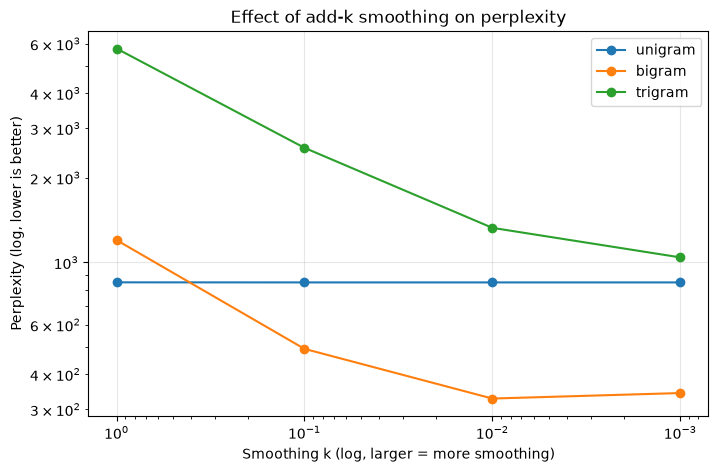

In [10]:
ks = [1.0, 0.1, 0.01, 0.001]
rows = []
for k in ks:
    r = [NgramModel(n, k=k).fit(train, vocab=vocab).perplexity(test)
         for n in (1, 2, 3)]
    rows.append(r)
    print(f'k={k:<6} | uni {r[0]:>8.1f} | bi {r[1]:>8.1f} | tri {r[2]:>8.1f}')

rows = np.array(rows)
plt.figure(figsize=(8, 5))
for j, label in enumerate(['unigram', 'bigram', 'trigram']):
    plt.plot(ks, rows[:, j], marker='o', label=label)
plt.xscale('log'); plt.yscale('log')
plt.gca().invert_xaxis()
plt.xlabel('Smoothing k (log, larger = more smoothing)')
plt.ylabel('Perplexity (log, lower is better)')
plt.title('Effect of add-k smoothing on perplexity')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## making the trigram actually win 
**Linear (Jelinek-Mercer) interpolation** blends all three orders:

$$P(w \mid w_{-2}, w_{-1}) = \lambda_3 P_{tri} + \lambda_2 P_{bi} + \lambda_1 P_{uni}, \quad \sum \lambda = 1.$$

When the trigram context is unseen, the bigram and unigram terms supply
robust probability mass. This recovers the high-order signal *without*
the over-smoothing penalty — and the interpolated trigram finally beats
the bigram.

In [11]:
interp = InterpolatedNgramModel(lambdas=(0.1, 0.3, 0.6), k=0.001)
interp.fit(train, vocab=vocab)
ppl_interp = interp.perplexity(test)
print(f'Interpolated trigram perplexity: {ppl_interp:.1f}')
print(f'  vs best add-k bigram          : {ppl_bi:.1f}')
print(f'  vs add-k trigram              : {ppl_tri:.1f}')

Interpolated trigram perplexity: 227.0
  vs best add-k bigram          : 327.9
  vs add-k trigram              : 1327.7


## Perplexity by order and Smoothing.

- `Lower Perplexity - better predictions.`

In [12]:
results = [
    ('Unigram',              'add-k (k=1, Laplace)', NgramModel(1, 1.0).fit(train, vocab=vocab).perplexity(test)),
    ('Unigram',              'add-k (k=0.01)',       ppl_uni),
    ('Bigram',               'add-k (k=1, Laplace)', NgramModel(2, 1.0).fit(train, vocab=vocab).perplexity(test)),
    ('Bigram',               'add-k (k=0.01)',       ppl_bi),
    ('Trigram',              'add-k (k=1, Laplace)', NgramModel(3, 1.0).fit(train, vocab=vocab).perplexity(test)),
    ('Trigram',              'add-k (k=0.01)',       ppl_tri),
    ('Trigram (interpolated)', 'interp + k=0.001',   ppl_interp),
]

print(f"{'Model':<24}{'Smoothing':<22}{'Perplexity':>12}")
print('-' * 58)
for name, sm, p in results:
    print(f'{name:<24}{sm:<22}{p:>12.1f}')

Model                   Smoothing               Perplexity
----------------------------------------------------------
Unigram                 add-k (k=1, Laplace)         849.5
Unigram                 add-k (k=0.01)               849.0
Bigram                  add-k (k=1, Laplace)        1200.7
Bigram                  add-k (k=0.01)               327.9
Trigram                 add-k (k=1, Laplace)        5767.6
Trigram                 add-k (k=0.01)              1327.7
Trigram (interpolated)  interp + k=0.001             227.0


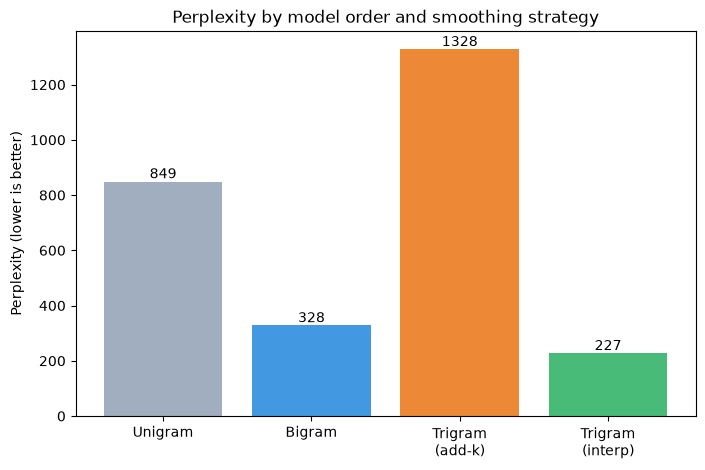

In [13]:
# Bar chart of the cleanest comparison: each order at k=0.01, plus interpolation.
labels = ['Unigram', 'Bigram', 'Trigram\n(add-k)', 'Trigram\n(interp)']
vals = [ppl_uni, ppl_bi, ppl_tri, ppl_interp]
colors = ['#a0aec0', '#4299e1', '#ed8936', '#48bb78']
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, vals, color=colors)
plt.ylabel('Perplexity (lower is better)')
plt.title('Perplexity by model order and smoothing strategy')
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width() / 2, v, f'{v:.0f}',
             ha='center', va='bottom')
plt.show()

## Generating Text

Higher orders produce more locally coherent text because they condition on more history.

In [14]:
def show(name, model, **kw):
    print(f'[{name}]')
    for s in (1, 7, 42):
        text = ' '.join(model.generate(length=20, seed_random=s, **kw))
        print(f'  seed {s:>2}: {text}')
    print()

show('Unigram (bag of words, no context)', unigram)
show('Bigram', bigram)
show('Trigram (add-k)', trigram)
show('Trigram (interpolated)', interp)

[Unigram (bag of words, no context)]
  seed  1: of fear make increase vs as money reporters said restrictions have income price 1987
  seed  7: a to asked the foreign in the only have the the will however of
  seed 42: within but

[Bigram]
  seed  1: the chain tied to their surroundings through with the bundesbank adequately and 6 7 5 6 mln net before he
  seed  7: o 2nd qtr and semi finished the same
  seed 42: while the meeting with so frightened her and its board is structured as a first half of interest and the

[Trigram (add-k)]
  seed  1: the carrier
  seed  7: corp lt
  seed 42: while it was a wide range in of the and black which fake therapeutic devices to effect a shift

[Trigram (interpolated)]
  seed  1: borg warner s spokeswoman said adding the sense of the could resume
  seed  7: he said
  seed 42: just like him to washington about 24 dlrs vs 3 from u k germany was to is seen reno



## Seed Phrases

model that has a starting Phase 


In [15]:
for seed in (['the', 'company'], ['it', 'is'], ['in', 'the']):
    cont = interp.generate(seed=seed, length=15, seed_random=3)
    print(f'{seed} -> {" ".join(cont)}')

['the', 'company'] -> the company said it received a price of the man who will sign on disarmament agreements and
['it', 'is'] -> it is not much needed coupled with the change on the horizon funding
['in', 'the'] -> in the village the gulf had pushed domestic use 13 9 pct


Unigram output turns out `No Context` since bigram is loacally pausable but drifts

## Developer 

# Matthew Ferrer - @2026
